In [289]:
import pandas as pd

import sqlite3

nba = sqlite3.connect('nba2024.db')

In [290]:
myquery = '''

SELECT *

FROM games

'''
pd.read_sql_query(myquery, con=nba)

,gameid,attendance,sellout,duration,regulationPeriods
0,22401186,17714,1,114,4
1,22401173,19752,1,129,4
2,22401169,17926,1,136,4
3,22401149,18846,1,142,4
4,22401136,16331,0,133,4
...,...,...,...,...,...
1226,22400237,14789,0,128,4
1227,22400752,18740,0,136,4
1228,22400469,18866,0,143,4
1229,22400260,14671,0,160,4


In [291]:
myquery = '''
SELECT *
FROM games
INNER JOIN teamgames
    ON games.gameid = teamgames.gameid
'''
pd.read_sql_query(myquery, con=nba)

,gameid,attendance,sellout,duration,regulationPeriods,season_id,teamid,team_abbreviation,team_name,gameid,...,oreb,dreb,reb,ast,stl,blk,tov,pf,plus_minus,HA
0,22401186,17714,1,114,4,22024,1610612737,ATL,Atlanta Hawks,22401186,...,9.0,35.0,44.0,32,8.0,2,15,15,12.0,Home
1,22401186,17714,1,114,4,22024,1610612753,ORL,Orlando Magic,22401186,...,12.0,31.0,43.0,25,11.0,5,14,8,-12.0,Away
2,22401173,19752,1,129,4,22024,1610612737,ATL,Atlanta Hawks,22401173,...,18.0,35.0,53.0,28,9.0,5,14,15,14.0,Away
3,22401173,19752,1,129,4,22024,1610612755,PHI,Philadelphia 76ers,22401173,...,14.0,31.0,45.0,29,6.0,6,14,17,-14.0,Home
4,22401169,17926,1,136,4,22024,1610612737,ATL,Atlanta Hawks,22401169,...,7.0,44.0,51.0,36,11.0,1,15,19,24.0,Away
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2457,22400469,18866,0,143,4,22024,1610612766,CHA,Charlotte Hornets,22400469,...,9.0,36.0,45.0,25,8.0,6,17,10,-4.0,Away
2458,22400260,14671,0,160,4,22024,1610612765,DET,Detroit Pistons,22400260,...,21.0,35.0,56.0,30,8.0,3,19,23,-2.0,Away
2459,22400260,14671,0,160,4,22024,1610612766,CHA,Charlotte Hornets,22400260,...,11.0,32.0,43.0,23,12.0,5,15,22,2.0,Home
2460,22400169,13247,0,132,4,22024,1610612765,DET,Detroit Pistons,22400169,...,6.0,40.0,46.0,34,5.0,4,10,20,-1.0,Away


In [292]:
# load team-level data
df = pd.read_sql_query("SELECT * FROM teamgames", nba)
# show structure
print(df.info())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2462 entries, 0 to 2461
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season_id          2462 non-null   int64  
 1   teamid             2462 non-null   int64  
 2   team_abbreviation  2462 non-null   object 
 3   team_name          2462 non-null   object 
 4   gameid             2462 non-null   int64  
 5   game_date          2462 non-null   object 
 6   matchup            2462 non-null   object 
 7   wl                 2462 non-null   object 
 8   min                2462 non-null   int64  
 9   pts                2462 non-null   int64  
 10  fgm                2462 non-null   int64  
 11  fga                2462 non-null   int64  
 12  fg_pct             2462 non-null   float64
 13  fg3m               2462 non-null   int64  
 14  fg3a               2462 non-null   float64
 15  fg3_pct            2462 non-null   float64
 16  ftm                2462 

# Checking the Structure and the data quality overall

This gives us:
- Data Types 
- Any missing values
- Summary Statistics

In [293]:
df.info()          # column names + dtypes + non-null counts    
print(df.describe())   #summary statistics for numeric columns
print()
print(df.isna().sum()) #any mssing values per column



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2462 entries, 0 to 2461
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   season_id          2462 non-null   int64  
 1   teamid             2462 non-null   int64  
 2   team_abbreviation  2462 non-null   object 
 3   team_name          2462 non-null   object 
 4   gameid             2462 non-null   int64  
 5   game_date          2462 non-null   object 
 6   matchup            2462 non-null   object 
 7   wl                 2462 non-null   object 
 8   min                2462 non-null   int64  
 9   pts                2462 non-null   int64  
 10  fgm                2462 non-null   int64  
 11  fga                2462 non-null   int64  
 12  fg_pct             2462 non-null   float64
 13  fg3m               2462 non-null   int64  
 14  fg3a               2462 non-null   float64
 15  fg3_pct            2462 non-null   float64
 16  ftm                2462 

### Understanding the data structure:

We have:

- 2462 rows: This makes sense 1 season × 30 teams × roughly 82 games = roughyl 2460 team-game rows
- 29 columns
- 0 missing values (great news! clean data = less preprocessing)

Statistical Summary:

- Points (pts) : Mean: 113.8, Min: 67, Max: 162
- Field goals (fgm, fga, fg_pct): Mean FG%: 0.468 (47%), so a High FG% = closer to winning.
- three-pointers (fg3m, fg3a, fg3_pct): FG3 attempts mean:  38 per game
- Rebounds (reb): Mean: 44.1, Variance: large, this appears to have a significance on games outcomes.
- Assists (ast): Mean: 26.5 more assist a team has, potentially higher chance of winning 
- Turnovers (tov): Mean: 13.5 More turnovers a team faces the less likely they are to win.
- Excluding: Plus-minus (plus_minus) Range: -59 to +59, this outcome depends on wins/loss 


### Preparing the data prior to making the decision tree model:

- Filtering to home team only
- changing wl to just be w=1 and l=0 (this is our target variable)
- Select predictive features (exclude IDs, text fields, and the Plus-Minus column)

In [294]:
# Filter for home team games only
home_df = df[df['HA'] == 'Home'].copy()

# Convert win/loss to binary target
home_df['target'] = home_df['wl'].map({'W': 1, 'L': 0})

# Select predictive features (exclude IDs, text fields, and leakage)
home_df = home_df.rename(columns={
    'pts': 'points',
    'fgm': 'fg_made',
    'fga': 'fg_attempts',
    'fg_pct': 'fg_percentage',
    'fg3m': 'threes_made',
    'fg3a': 'threes_attempts',
    'fg3_pct': 'threes_percentage',
    'ftm': 'ft_made',
    'fta': 'ft_attempts',
    'ft_pct': 'ft_percentage',
    'oreb': 'offensive_rebounds',
    'dreb': 'defensive_rebounds',
    'reb': 'total_rebounds',
    'ast': 'assists',
    'stl': 'steals',
    'blk': 'blocks',
    'tov': 'turnovers',
    'pf': 'personal_fouls'
})

feature_cols = [
    'points', 'fg_made', 'fg_attempts', 'fg_percentage',
    'threes_made', 'threes_attempts', 'threes_percentage',
    'ft_made', 'ft_attempts', 'ft_percentage',
    'offensive_rebounds', 'defensive_rebounds', 'total_rebounds',
    'assists', 'steals', 'blocks',
    'turnovers', 'personal_fouls'
]


#Defining X (features) and y (target)

X = home_df[feature_cols]
y = home_df['target']

#checking the shape and understanding the dataframe:
print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())


X shape: (1225, 18)
y distribution:
target
1    667
0    558
Name: count, dtype: int64


### Exploring the data prior to making the decision tree model:

- Histograms for key statistics
- Boxplots comparing Wins vs Losses
- Correlation matrix to see relationships between variables
- Perhaps even a heat map
- 

HA
Home    1225
Name: count, dtype: int64
home_df shape: (1225, 30)


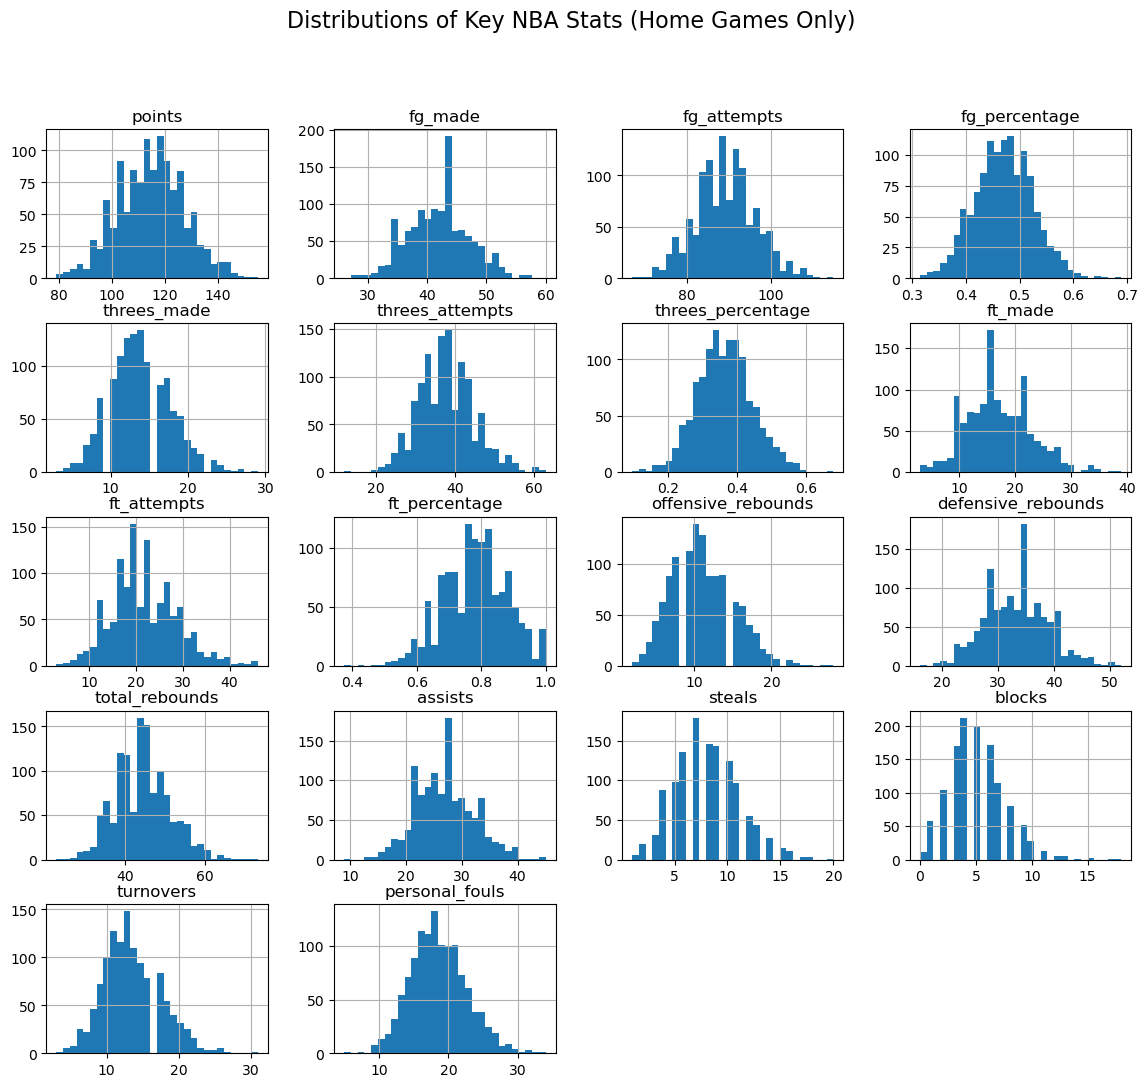

In [295]:
# Sanity check
print(home_df['HA'].value_counts())
print("home_df shape:", home_df.shape)

#running the histogram for key statistics
import matplotlib.pyplot as plt

home_df[feature_cols].hist(figsize=(14, 12), bins=30)
plt.suptitle("Distributions of Key NBA Stats (Home Games Only)", fontsize=16)
plt.show()




### Boxplots of Wins vs Looses 

We will visualize the distribution of key statistics for wins and losses using boxplots. This will help us identify which statistics have significant differences between winning and losing games.

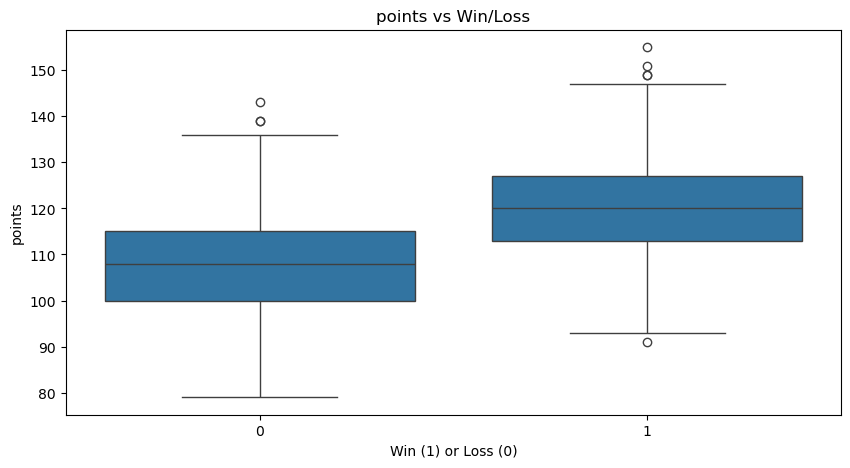

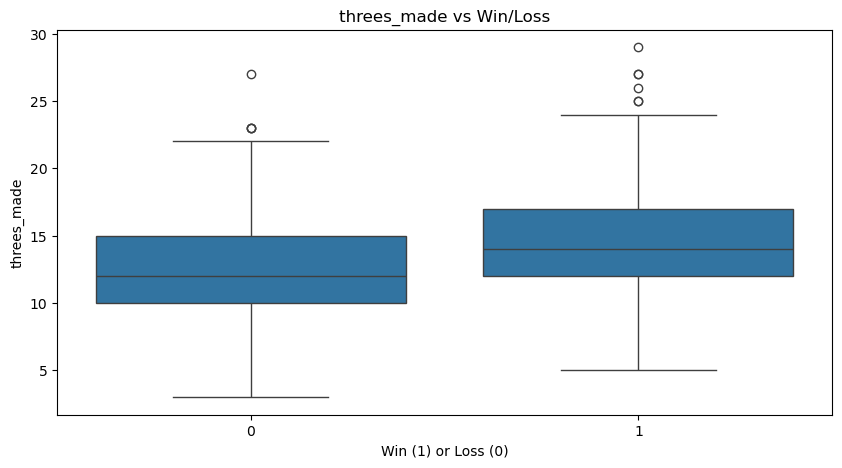

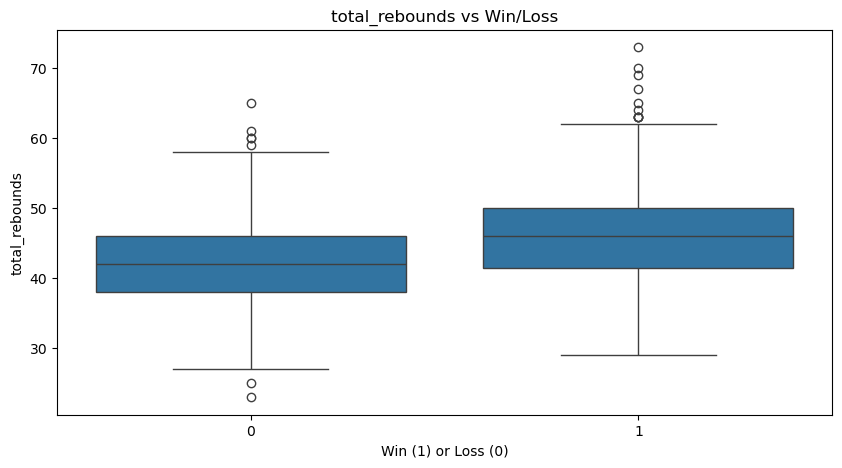

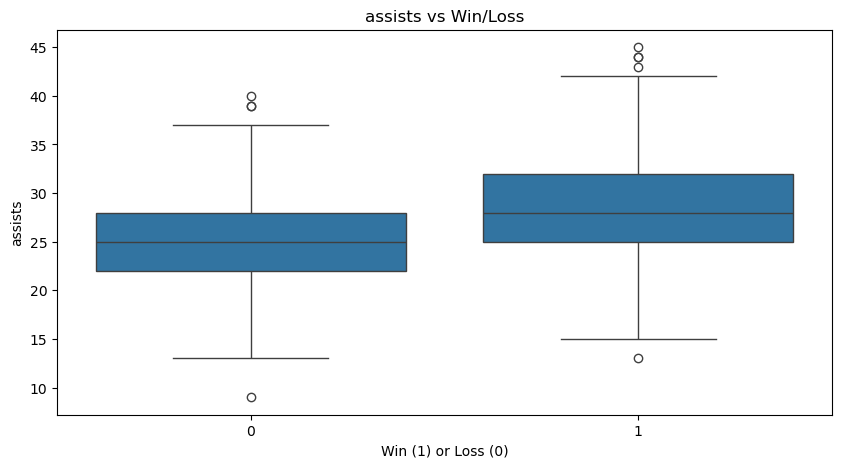

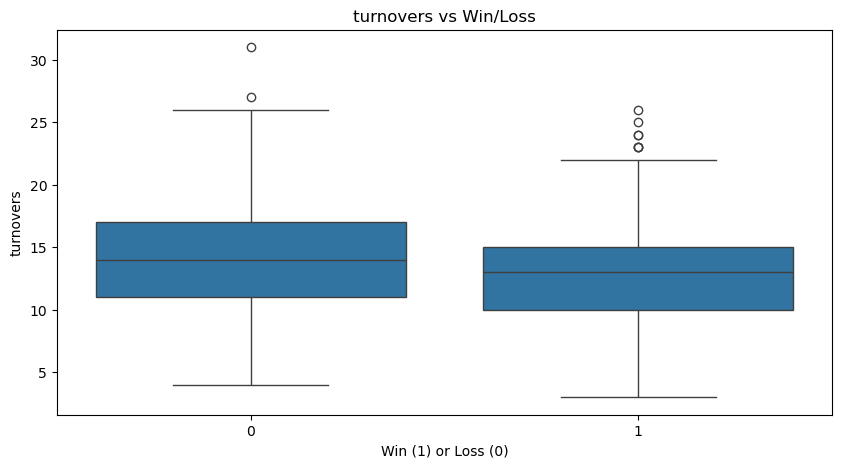

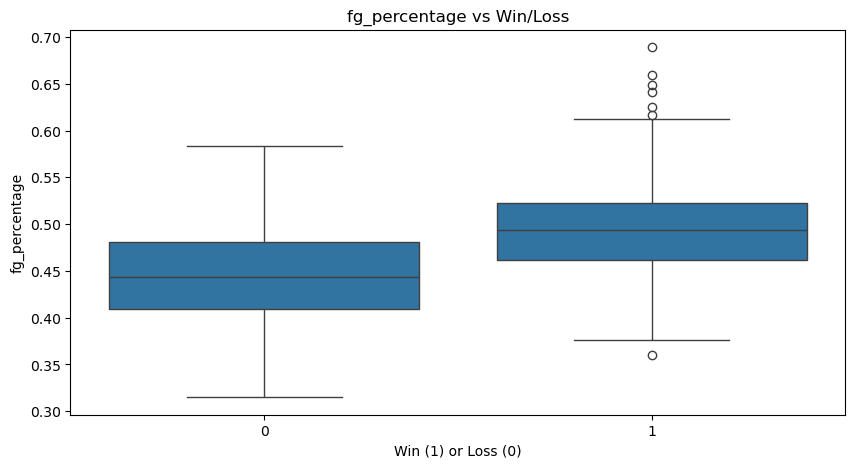

In [296]:
import seaborn as sns
import matplotlib.pyplot as plt

for stat in ['points', 'threes_made', 'total_rebounds', 'assists', 'turnovers', 'fg_percentage']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=home_df, x='target', y=stat)
    plt.title(f"{stat} vs Win/Loss")
    plt.xlabel("Win (1) or Loss (0)")
    plt.show()


- Interpretation:
    - Points (pts): Winning teams have a higher median and tend to have a higher average ranging from roughly 120-130 points.
    - We see how turnovers tend to be lower for winning teams, indicating that minimizing turnovers is crucial for winning games. and we see that the median for loosing teams si slightly higher.

### Developing a Correlation Matrix:
To see what features might influence winning the most, we will create a correlation matrix to visualize the relationships between different variables in the dataset. This will help us identify which statistics are most strongly associated with winning games.


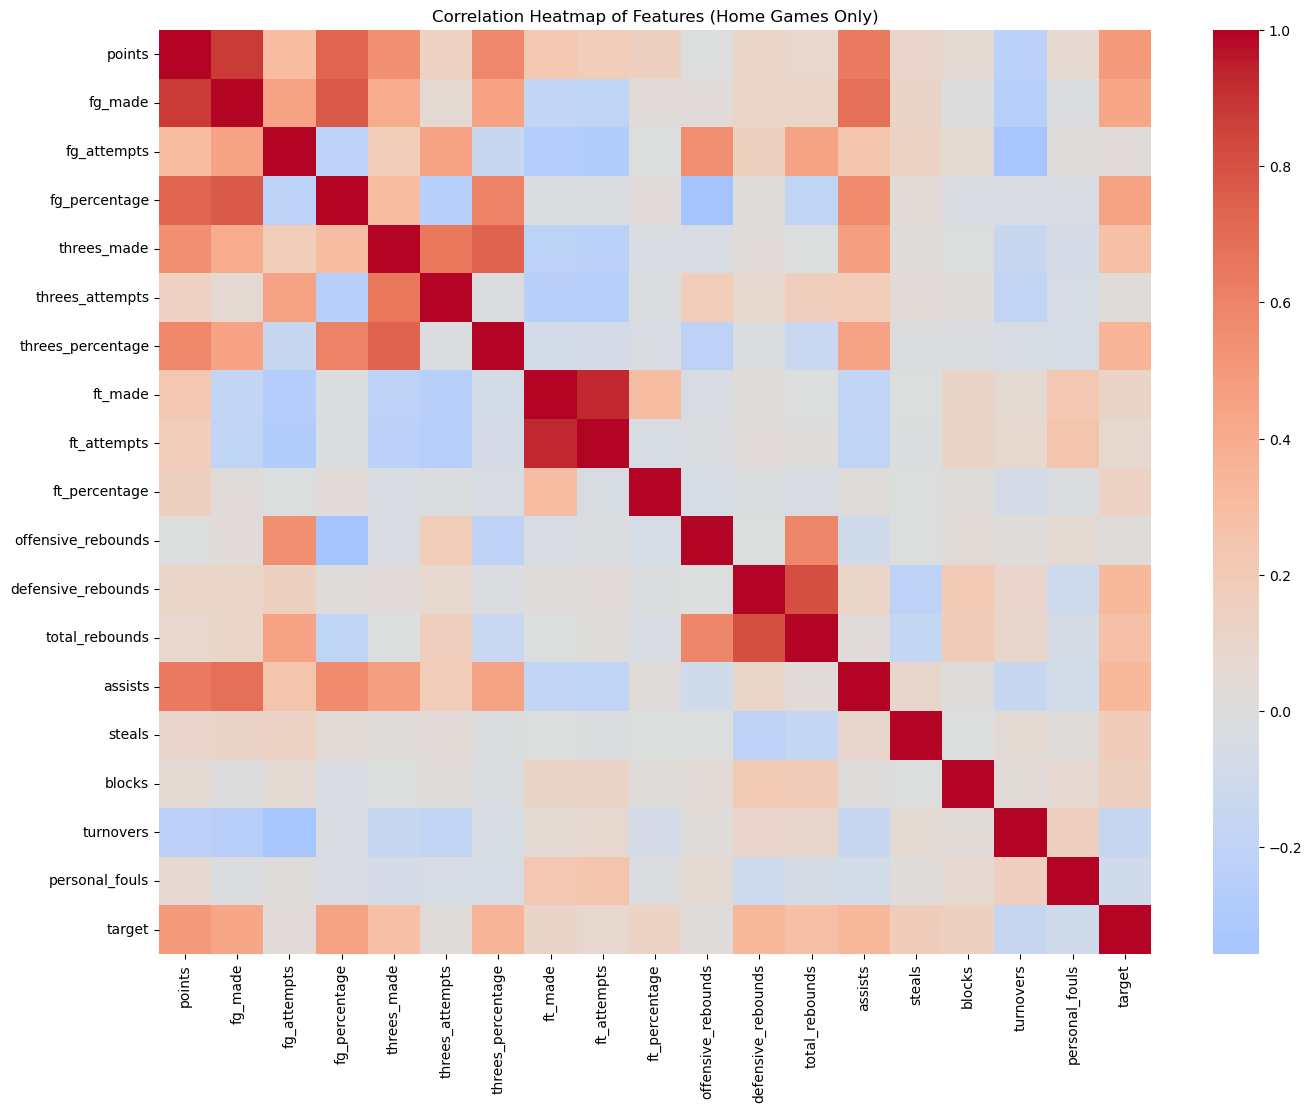

target                1.000000
points                0.499401
fg_percentage         0.450531
fg_made               0.433263
threes_percentage     0.356820
defensive_rebounds    0.329750
assists               0.329477
threes_made           0.284722
total_rebounds        0.278651
steals                0.176616
blocks                0.153145
ft_percentage         0.126820
ft_made               0.111034
ft_attempts           0.073389
fg_attempts           0.028107
offensive_rebounds    0.020361
threes_attempts       0.017146
personal_fouls       -0.099436
turnovers            -0.156595
Name: target, dtype: float64

In [297]:
corr = home_df[feature_cols + ['target']].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Features (Home Games Only)")
plt.show()

# See which features correlate most with winning
corr['target'].sort_values(ascending=False)

We see that the following tend to correlate the strongest with winning (home team):
- points                0.499401
- fg_percentage         0.450531
- fg_made               0.433263
- threes_percentage     0.356820
- defensive_rebounds    0.329750
- assists               0.329477
- threes_made           0.284722
- total_rebounds        0.278651

These features show a negative correlation with the target:
- personal_fouls       -0.099436
- turnovers            -0.156595
- Interpretation:Teams that win tend to turn the ball over less. Fouling excessively reduces win probability (gives opponents free throws), which also aligns with basketball fundamentals.

Because several offensive statistics are strongly inter-correlated (e.g., points, FG made, FG attempts, threes_made, threes_attempts), the decision tree is expected to select only the most informative features from each cluster.  In other words Winning teams, Score more, Shoot more efficiently (FG%, 3PT%, FT%), Assist more, Rebound more, Turn the ball over less.


### Beginning to build the decision tree
Below we do an 80/20 train-test split and build a decision tree classifier to predict home team wins based on the selected features. We will evaluate the model's accuracy on the test set to see how well it performs.

In [298]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training distribution:\n", y_train.value_counts(normalize=True))
print("Testing distribution:\n", y_test.value_counts(normalize=True))



Training shape: (980, 18)
Testing shape: (245, 18)
Training distribution:
 target
1    0.544898
0    0.455102
Name: proportion, dtype: float64
Testing distribution:
 target
1    0.542857
0    0.457143
Name: proportion, dtype: float64


In [299]:
#after the split we train the decision tree model

dt = DecisionTreeClassifier(
    max_depth=None,   # grow full tree first
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [300]:
#checking the basic performance of our decision tree:
#this will give us: Accuracy, Precision, Recall, and F1-score

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.746938775510204

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.71      0.72       112
           1       0.76      0.77      0.77       133

    accuracy                           0.75       245
   macro avg       0.75      0.74      0.74       245
weighted avg       0.75      0.75      0.75       245



The baseline decision tree achieved an accuracy of approximately 75%, with balanced performance across both win and loss classes. The model performed slightly better at predicting home wins (precision = 0.76, recall = 0.77) than home losses, which is consistent with the natural home-court advantage present in NBA games. These results indicate that box score statistics contain meaningful predictive signals for game outcomes, even with a simple tree-based model.”

### Training the tree with different max depths to see which is the best:


In [301]:
#testing a range of depths of trees from something shallow to deep
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

depths = [3, 4, 5, 6, 7,8,9, None]  # None = full tree
results = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append((d, acc, f1))

results


[(3, 0.7714285714285715, 0.7795275590551181),
 (4, 0.7714285714285715, 0.7925925925925926),
 (5, 0.7795918367346939, 0.8),
 (6, 0.7387755102040816, 0.7762237762237763),
 (7, 0.7428571428571429, 0.7692307692307693),
 (8, 0.726530612244898, 0.7581227436823105),
 (9, 0.7591836734693878, 0.7870036101083032),
 (None, 0.746938775510204, 0.7686567164179104)]

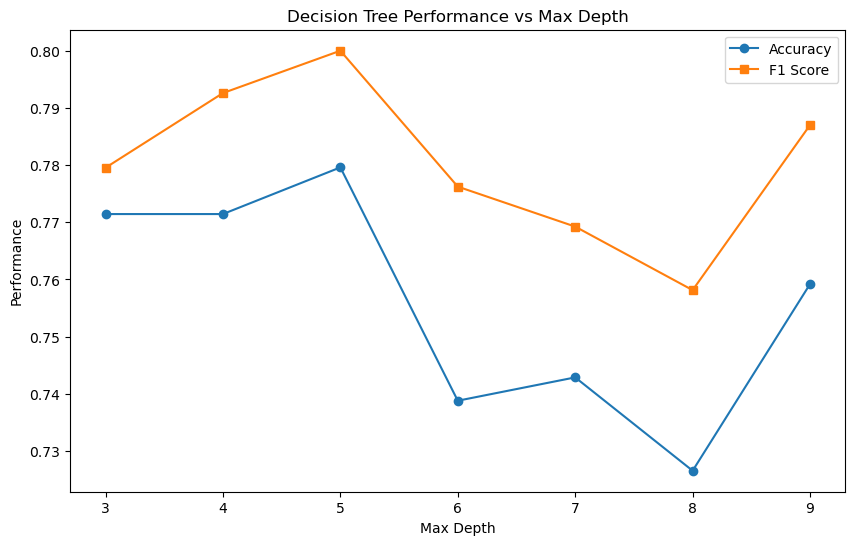

   max_depth  accuracy        f1
0        3.0  0.771429  0.779528
1        4.0  0.771429  0.792593
2        5.0  0.779592  0.800000
3        6.0  0.738776  0.776224
4        7.0  0.742857  0.769231
5        8.0  0.726531  0.758123
6        9.0  0.759184  0.787004
7        NaN  0.746939  0.768657


In [302]:
#converting the output of the various depths into a dataframe for easier visualization
df_results = pd.DataFrame(results, columns=['max_depth', 'accuracy', 'f1'])

plt.figure(figsize=(10,6))
plt.plot(df_results['max_depth'], df_results['accuracy'], marker='o', label='Accuracy')
plt.plot(df_results['max_depth'], df_results['f1'], marker='s', label='F1 Score')
plt.xlabel("Max Depth")
plt.ylabel("Performance")
plt.title("Decision Tree Performance vs Max Depth")
plt.legend()
plt.show()

print(df_results)

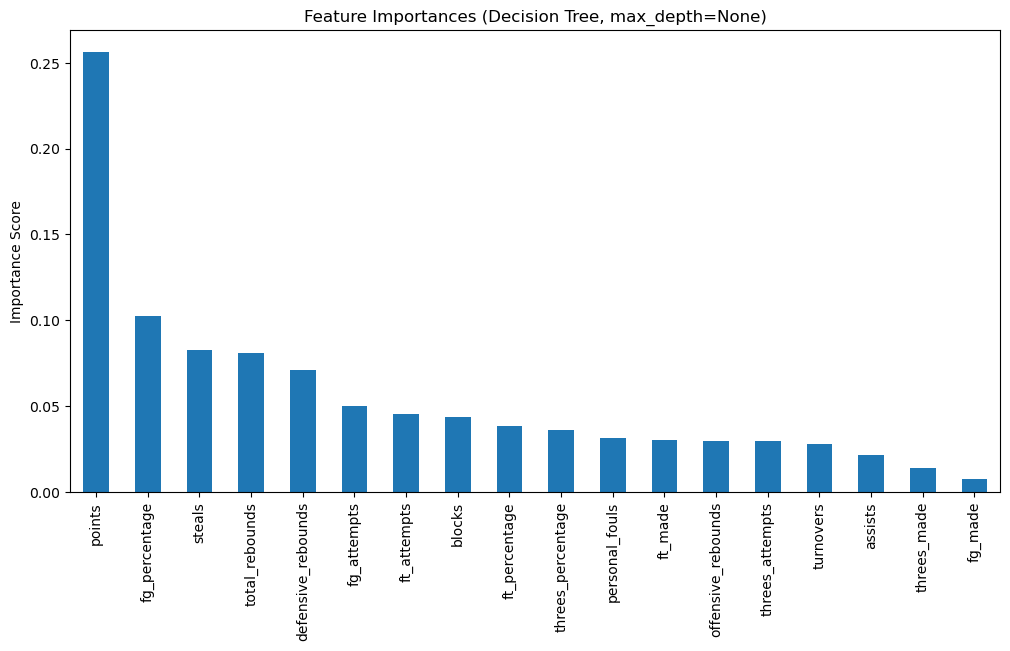

fg_made               0.007793
threes_made           0.014264
assists               0.021284
turnovers             0.027999
threes_attempts       0.029854
offensive_rebounds    0.029967
ft_made               0.030056
personal_fouls        0.031629
threes_percentage     0.035897
ft_percentage         0.038280
blocks                0.043958
ft_attempts           0.045658
fg_attempts           0.050266
defensive_rebounds    0.071036
total_rebounds        0.081115
steals                0.082430
fg_percentage         0.102282
points                0.256231
dtype: float64

In [303]:
#looking at feature importance from the decision tree see which one really effects our home team win:
dt_full = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_full.fit(X_train, y_train)

importances = pd.Series(dt_full.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Feature Importances (Decision Tree, max_depth=None)")
plt.ylabel("Importance Score")
plt.show()

importances.sort_values(ascending=True)

In [304]:
results

[(3, 0.7714285714285715, 0.7795275590551181),
 (4, 0.7714285714285715, 0.7925925925925926),
 (5, 0.7795918367346939, 0.8),
 (6, 0.7387755102040816, 0.7762237762237763),
 (7, 0.7428571428571429, 0.7692307692307693),
 (8, 0.726530612244898, 0.7581227436823105),
 (9, 0.7591836734693878, 0.7870036101083032),
 (None, 0.746938775510204, 0.7686567164179104)]

I evaluated decision trees with varying maximum depths ranging from 3 to a fully grown tree. Model performance peaked at a maximum depth of 5, which achieved the highest accuracy (0.77) and F1-score (0.800). Shallower trees (depth 3–4) underfit the data and failed to capture important relationships between features, while deeper trees (depth 6 and above) began to overfit, causing test performance to decline. Notably, the fully grown tree (max_depth=None) performed worse than the pruned depth-5 model, confirming that controlled tree depth improves generalization.

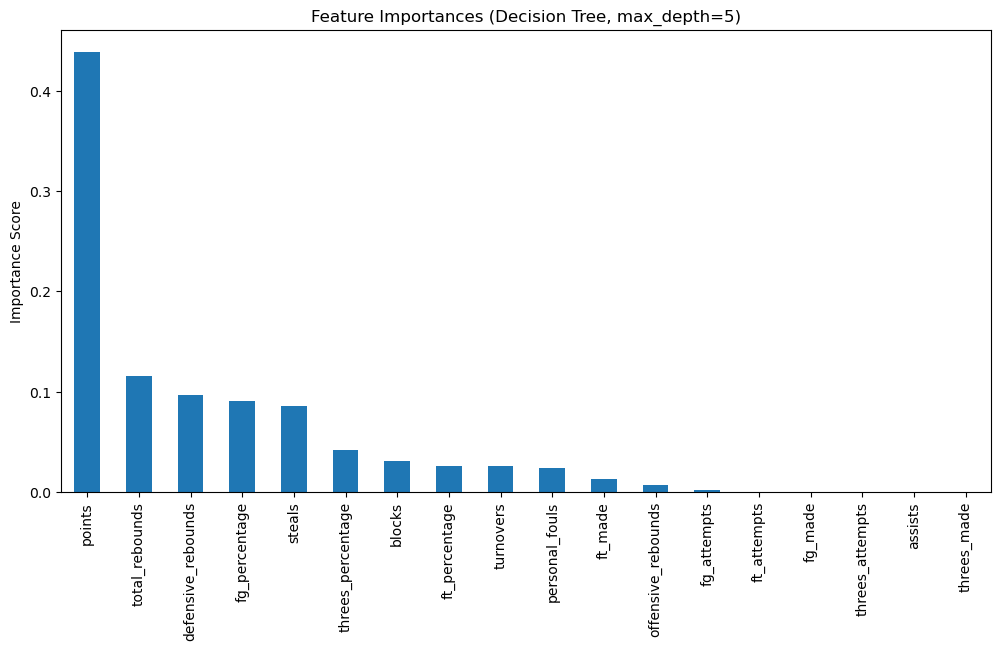

points                0.438576
total_rebounds        0.115785
defensive_rebounds    0.097077
fg_percentage         0.090820
steals                0.085987
threes_percentage     0.041948
blocks                0.031257
ft_percentage         0.026207
turnovers             0.025908
personal_fouls        0.024411
ft_made               0.013380
offensive_rebounds    0.006807
fg_attempts           0.001837
ft_attempts           0.000000
fg_made               0.000000
threes_attempts       0.000000
assists               0.000000
threes_made           0.000000
dtype: float64

In [305]:
#lets look at the feature importance to see which statistics are the most influential in predicting home team wins.
dt_best = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_best.fit(X_train, y_train)

importances = pd.Series(dt_best.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Feature Importances (Decision Tree, max_depth=5)")
plt.ylabel("Importance Score")
plt.show()

importances.sort_values(ascending=False)


Feature importance analysis reveals that the most influential predictors of home-team victory are points scored, shooting efficiency (FG%), and rebounding metrics (total and defensive rebounds). The pruned decision tree (max_depth=5) assigns over 40% of its total importance to points alone, underscoring its role as the strongest signal in predicting outcomes. Additional contributions come from steals, three-point percentage, and turnovers, all aligning with basketball intuition. In contrast, the fully grown tree distributes importance more diffusely across many low-impact splits, confirming that the pruned model provides a clearer and more interpretable structure.”

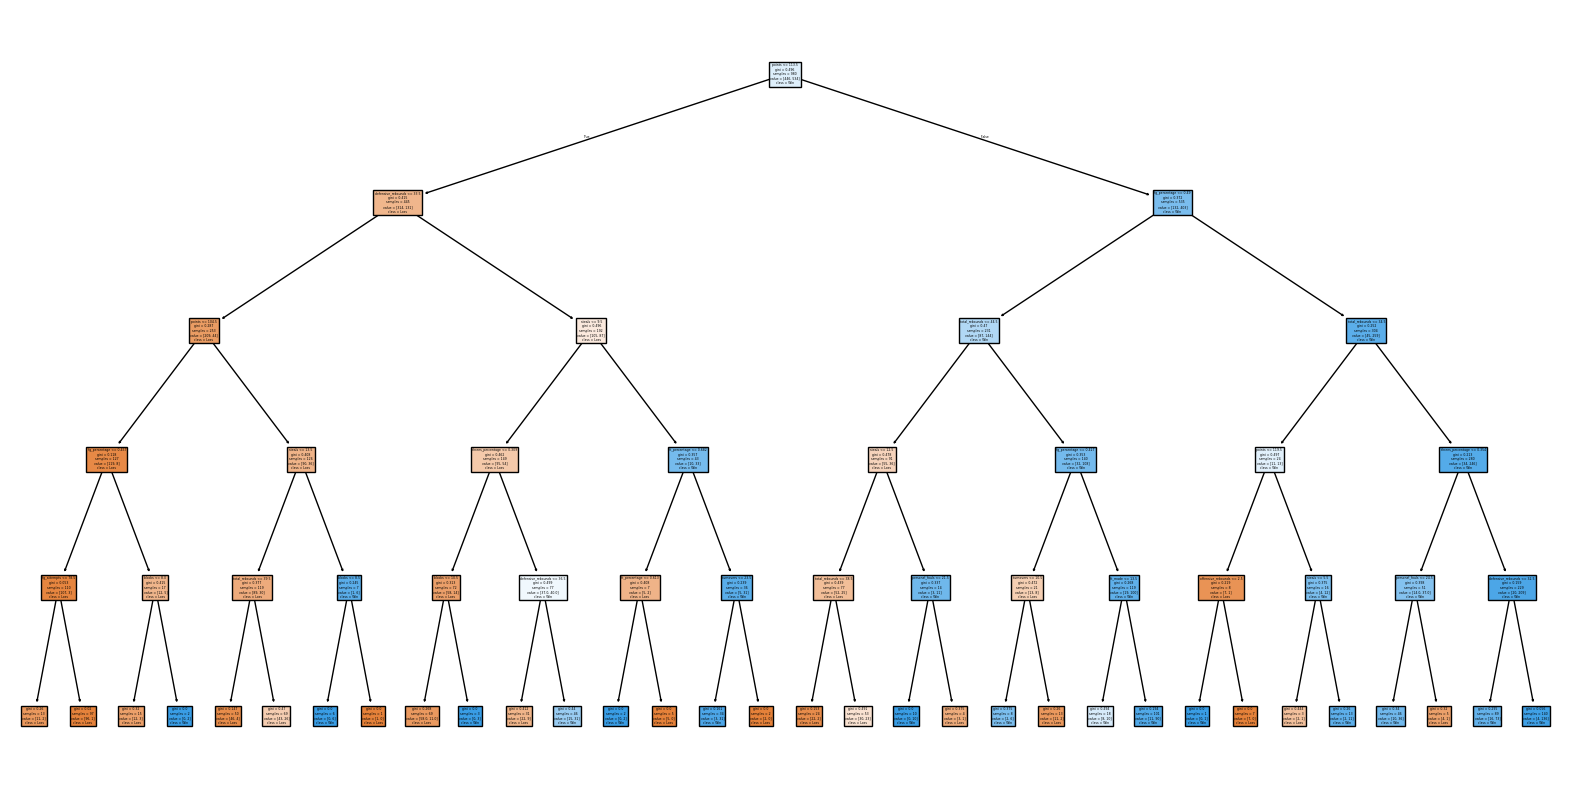

In [306]:
#attempting to make a decision tree visualization for max_depth=5
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_best, feature_names=feature_cols, class_names=['Loss','Win'], filled=True)
plt.show()


Before evaluating a model, we compare it to simple baselines to show that the model actually adds value.

**Baseline 1: Majority Class Predictor**
The simplest possible classifier predicts the most common class every time. As we can see the baseline has an accuracy of roughly 54% meanwhile the f-1 score for home winning is 70%. meanwhile our tree with the optimal depth of 5 has an accuracy of roughly 77.95% and an F-1 score of 80%. 

In [307]:
majority_class = y_train.mode()[0]
baseline_pred = [majority_class] * len(y_test)

from sklearn.metrics import accuracy_score, f1_score
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

baseline_acc, baseline_f1


(0.5428571428571428, 0.7037037037037037)

The pruned decision tree (max_depth=5) demonstrates clearly superior predictive performance compared to both the majority baseline and the fully grown tree. This confirms the value of controlled tree depth and shows that game statistics meaningfully improve prediction of NBA outcomes beyond what is explained by the natural home-court advantage alone.

# Discussing time complexity, prediction compleicity, and space complexity of decision trees
Decision trees have a time complexity of O(n log n) for training, where n is the number of samples. This is because the algorithm needs to sort the data at each node to find the best split. For prediction, the time complexity is O(h), where h is the height of the tree. In the worst case, the height can be equal to the number of samples (O(n)), but with balanced trees, it is typically O(log n). 

Below I measured training time, prediction time, and node count for two models:

- Depth-5 tree (best model)
- Fully grown tree (max_depth = None)


In [308]:
import time
#Depth=5
start_train = time.time()
dt5 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt5.fit(X_train, y_train)
end_train = time.time()

start_pred = time.time()
pred_dt5 = dt5.predict(X_test)
end_pred = time.time()

train_time_5 = end_train - start_train
pred_time_5 = end_pred - start_pred

# Full tree
start_train_full = time.time()
dt_full = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_full.fit(X_train, y_train)
end_train_full = time.time()

start_pred_full = time.time()
pred_full = dt_full.predict(X_test)
end_pred_full = time.time()

train_time_full = end_train_full - start_train_full
pred_time_full = end_pred_full - start_pred_full

# Node counts
nodes_5 = dt5.tree_.node_count
nodes_full = dt_full.tree_.node_count

#getting our final output:
results_summary = pd.DataFrame({
    'Model': ['Depth=5', 'Full Tree'],
    'Training Time (s)': [train_time_5, train_time_full],
    'Prediction Time (s)': [pred_time_5, pred_time_full],
    'Node Count': [nodes_5, nodes_full]
})
print(results_summary)


       Model  Training Time (s)  Prediction Time (s)  Node Count
0    Depth=5           0.004127             0.000490          63
1  Full Tree           0.004431             0.000292         295


In [309]:
print(home_df.head())

    season_id      teamid team_abbreviation      team_name    gameid  \
0       22024  1610612737               ATL  Atlanta Hawks  22401186   
4       22024  1610612737               ATL  Atlanta Hawks  22401136   
5       22024  1610612737               ATL  Atlanta Hawks  22401128   
7       22024  1610612737               ATL  Atlanta Hawks  22401097   
11      22024  1610612737               ATL  Atlanta Hawks  22401031   

     game_date      matchup wl  min  points  ...  defensive_rebounds  \
0   2025-04-13  ATL vs. ORL  W  241     117  ...                35.0   
4   2025-04-06  ATL vs. UTA  W  239     147  ...                31.0   
5   2025-04-05  ATL vs. NYK  L  240     105  ...                29.0   
7   2025-04-01  ATL vs. POR  L  241     113  ...                33.0   
11  2025-03-23  ATL vs. PHI  W  240     132  ...                29.0   

    total_rebounds  assists  steals  blocks  turnovers  personal_fouls  \
0             44.0       32     8.0       2         15      

In [310]:
home_df.head()


,season_id,teamid,team_abbreviation,team_name,gameid,game_date,matchup,wl,min,points,...,defensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,plus_minus,HA,target
0,22024,1610612737,ATL,Atlanta Hawks,22401186,2025-04-13,ATL vs. ORL,W,241,117,...,35.0,44.0,32,8.0,2,15,15,12.0,Home,1
4,22024,1610612737,ATL,Atlanta Hawks,22401136,2025-04-06,ATL vs. UTA,W,239,147,...,31.0,42.0,43,7.0,3,11,19,13.0,Home,1
5,22024,1610612737,ATL,Atlanta Hawks,22401128,2025-04-05,ATL vs. NYK,L,240,105,...,29.0,38.0,24,11.0,7,15,18,-16.0,Home,0
7,22024,1610612737,ATL,Atlanta Hawks,22401097,2025-04-01,ATL vs. POR,L,241,113,...,33.0,45.0,26,12.0,8,19,22,-14.0,Home,0
11,22024,1610612737,ATL,Atlanta Hawks,22401031,2025-03-23,ATL vs. PHI,W,240,132,...,29.0,39.0,35,11.0,4,16,26,13.0,Home,1


### Pie Chart of Win/Loss Distirbution 

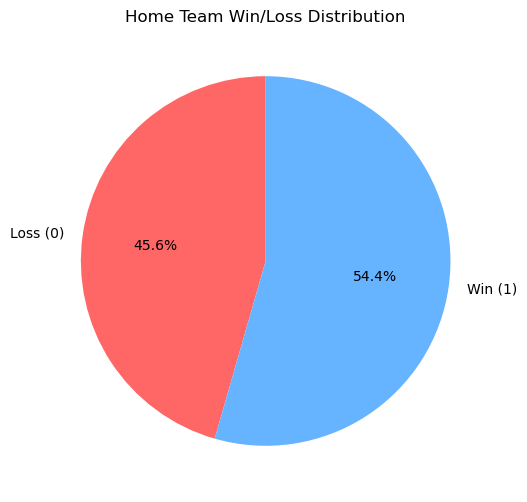

In [311]:
# Win/loss distribution
labels = ['Loss (0)', 'Win (1)']
sizes = y.value_counts().sort_index()  # ensures 0 then 1 order
colors = ['#ff6666', '#66b3ff']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title("Home Team Win/Loss Distribution")
plt.show()

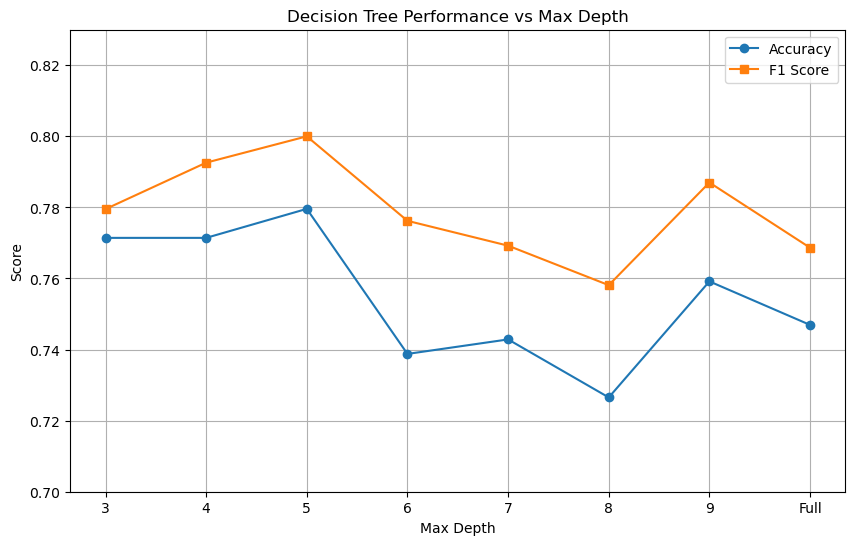

In [312]:
import matplotlib.pyplot as plt

depths = [3,4,5,6,7,8,9,'Full']
accuracy = [0.771429,0.771429,0.779592,0.738776,0.742857,0.726531,0.759184,0.746939]
f1 = [0.779528,0.792593,0.800000,0.776224,0.769231,0.758123,0.787004,0.768657]

plt.figure(figsize=(10,6))
plt.plot(depths, accuracy, marker='o', label="Accuracy")
plt.plot(depths, f1, marker='s', label="F1 Score")

plt.title("Decision Tree Performance vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.ylim(0.70, 0.83)
plt.grid(True)
plt.legend()
plt.show()


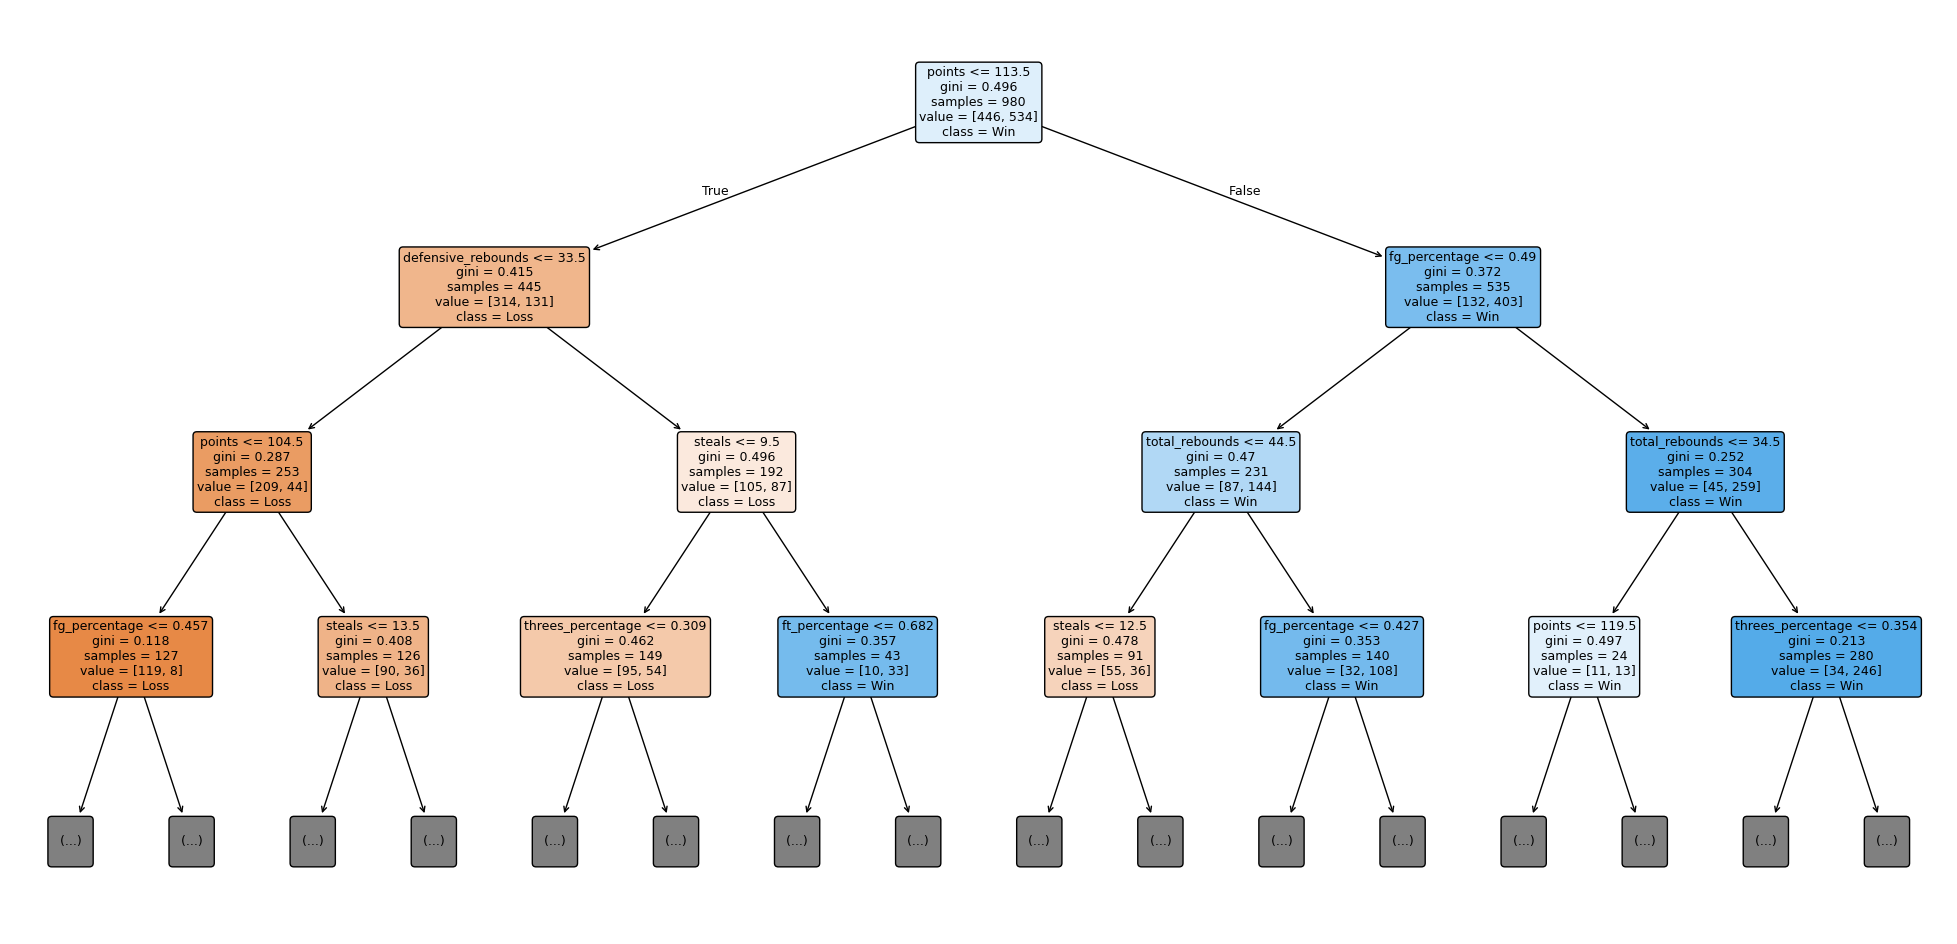

In [313]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 12))  # BIGGER and readable
plot_tree(dt5, 
          feature_names=feature_cols, 
          class_names=['Loss', 'Win'], 
          filled=True, 
          rounded=True, 
          fontsize=9, 
          max_depth=3  # Only show top 3 layers
)
plt.show()
